In [23]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [24]:
DATA = Path("../data")

COUNTIES = DATA / "raw/census/cb_2018_us_county_20m.shp"

BLACK_BELT = DATA / "processed/black_belt_al_ms_dissolved.geojson"

COUNTY_FEATURES = DATA / "processed/counties_al_ms_black_belt_features.geojson"

In [25]:
counties = gpd.read_file(COUNTIES)

black_belt = gpd.read_file(BLACK_BELT)

features = gpd.read_file(COUNTY_FEATURES)

In [26]:
COMMON_CRS = "EPSG:5070"

counties = counties.to_crs(COMMON_CRS)
black_belt = black_belt.to_crs(COMMON_CRS)
features = features.to_crs(COMMON_CRS)

In [27]:
state_fips = {"01", "28"}

counties = counties[counties["STATEFP"].isin(state_fips)].copy()

In [28]:
print("Counties:", counties.shape)
print("Features:", features.shape)

features.head()

Counties: (149, 10)
Features: (149, 10)


,STATEFP,COUNTYFP,GEOID,NAME,intersects_black_belt,centroid_in_black_belt,dist_to_black_belt_km,centroid_x,centroid_y,geometry
0,01,043,01043,Cullman,False,False,150.007508,834568.776784,1.269660e+06,"POLYGON ((813867.623 1252211.812, 810853.035 1..."
1,01,059,01059,Franklin,False,False,59.493919,742801.372299,1.296358e+06,"POLYGON ((714262.312 1296237.428, 714559.688 1..."
2,01,023,01023,Choctaw,False,False,53.228702,726343.525491,1.023826e+06,"POLYGON ((708460.493 1008043.571, 708113.978 1..."
3,01,109,01109,Pike,True,False,9.467288,946468.853282,1.020101e+06,"POLYGON ((921175.012 1035624.607, 939484.833 1..."
4,28,115,28115,Pontotoc,True,False,2.409653,636099.865630,1.263562e+06,"POLYGON ((615737.072 1279269.531, 644629.625 1..."


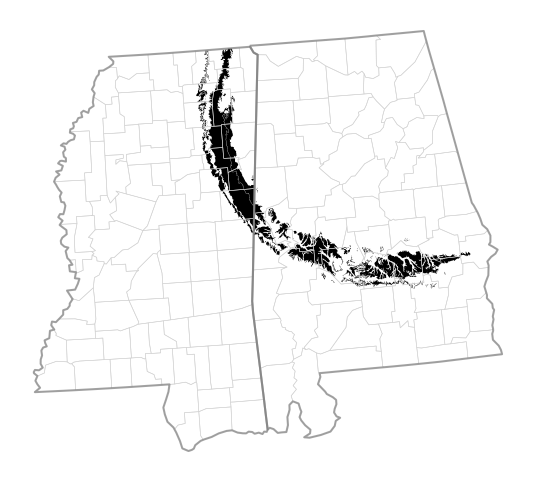

In [29]:

import geopandas as gpd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

# County boundaries
counties.boundary.plot(
    ax=ax,
    color="lightgrey",
    linewidth=0.4,
)

# Black Belt
black_belt.plot(
    ax=ax,
    color="black",
)

# ---------------------------------------------------
# Extract Alabama and Mississippi states from counties
# ---------------------------------------------------

states = (
    counties[counties["STATEFP"].isin(["01", "28"])]
    .dissolve(by="STATEFP")
)

# Plot state borders
states.boundary.plot(
    ax=ax,
    color="gray",
    alpha=0.7,
    linewidth=1.5,
)

ax.set_axis_off()

plt.savefig("../data/processed/map_boundary_black_belt.png", dpi=300, bbox_inches="tight")

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

COMMON_CRS = "EPSG:5070"

BLACK_BELT = Path("../data/processed/black_belt_al_ms_dissolved.geojson")
COUNTY_FEATURES = Path("../data/processed/counties_al_ms_black_belt_features.geojson")

MAP_BOUNDARY = Path("../data/raw/geology/usgs_mississippi_alluvial_plain/Mississippi_Alluvial_Plain.shp")

In [31]:
features = gpd.read_file(COUNTY_FEATURES).to_crs(COMMON_CRS)
map_boundary = gpd.read_file(MAP_BOUNDARY).to_crs(COMMON_CRS)

print(map_boundary.columns.tolist())
map_boundary.head()

['AREA', 'PERIMETER', 'PHYSREG_', 'PHYSREG_ID', 'ZONE', 'NAME', 'geometry']


,AREA,PERIMETER,PHYSREG_,PHYSREG_ID,ZONE,NAME,geometry
0,1.854410e+10,1.159665e+06,5,0,4,Delta,"POLYGON ((505422.358 1323283.146, 505530.157 1..."


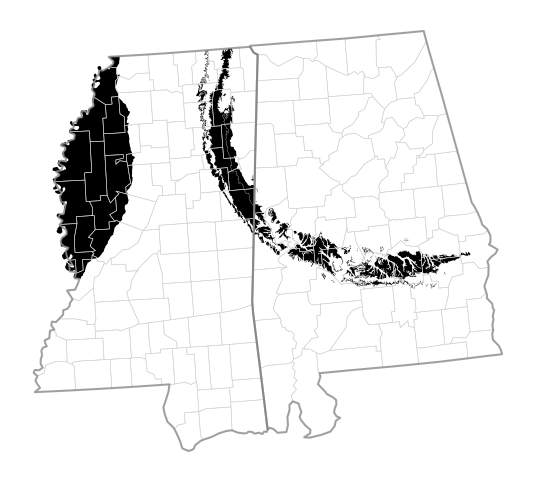

In [32]:

import geopandas as gpd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

# County boundaries
counties.boundary.plot(
    ax=ax,
    color="lightgrey",
    linewidth=0.4,
)

# Black Belt
black_belt.plot(
    ax=ax,
    color="black",
)

# ---------------------------------------------------
# Extract Alabama and Mississippi states from counties
# ---------------------------------------------------

states = (
    counties[counties["STATEFP"].isin(["01", "28"])]
    .dissolve(by="STATEFP")
)

# Plot state borders
states.boundary.plot(
    ax=ax,
    color="gray",
    alpha=0.7,
    linewidth=1.5,
)

map_boundary.plot(ax=ax, color="black", linewidth=1.5,alpha=1, label="Mississippi Alluvial Plain")
ax.set_axis_off()

plt.savefig("../data/processed/map_boundary_black_belt_and_mississippi_alluvial_plain.png", dpi=300, bbox_inches="tight")

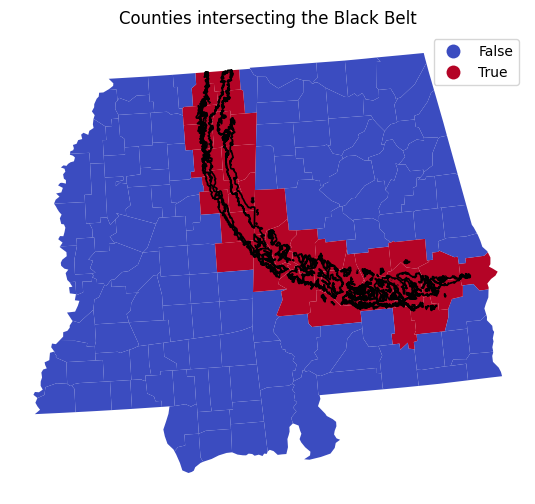

In [33]:
fig, ax = plt.subplots(figsize=(10,6))

features.plot(
    ax=ax,
    column="intersects_black_belt",
    cmap="coolwarm",
    legend=True,
)

black_belt.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

ax.set_title("Counties intersecting the Black Belt")

ax.set_axis_off()

plt.show()

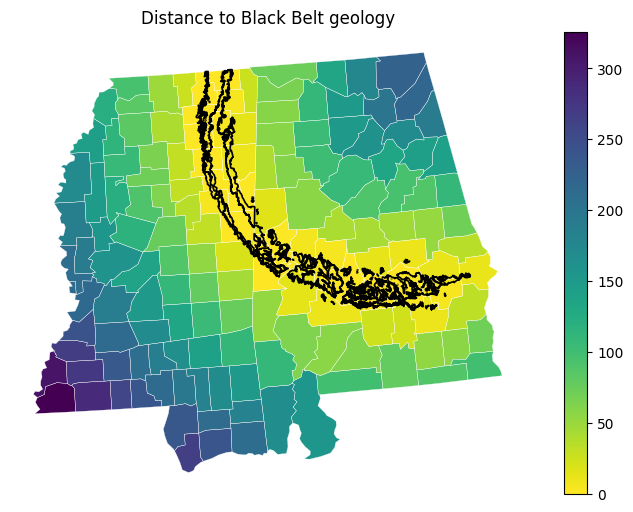

In [34]:
fig, ax = plt.subplots(figsize=(10,6))

features.plot(
    ax=ax,
    column="dist_to_black_belt_km",
    cmap="viridis_r",
    legend=True,
)

features.boundary.plot(
    ax=ax,
    color="white",
    linewidth=0.2
)

black_belt.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

ax.set_title("Distance to Black Belt geology")

ax.set_axis_off()

plt.show()

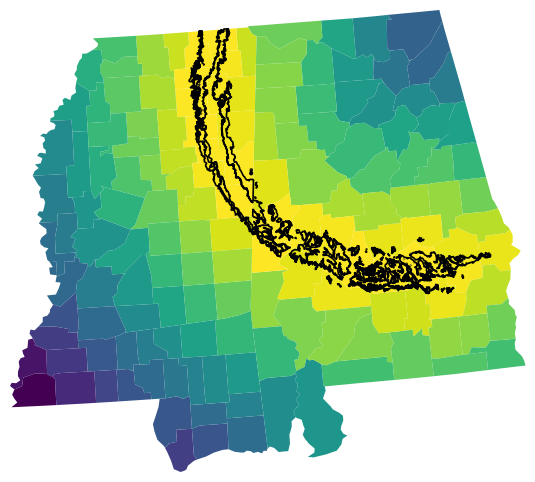

In [35]:
xmin, ymin, xmax, ymax = counties.total_bounds

fig, ax = plt.subplots(figsize=(10,6))

features.plot(
    ax=ax,
    column="dist_to_black_belt_km",
    cmap="viridis_r",
)

black_belt.boundary.plot(ax=ax, color="black", linewidth=1.2)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_axis_off()

plt.show()